### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
facturacion_tienda1 = tienda["Precio"].sum()
facturacion_tienda2 = tienda2["Precio"].sum()
facturacion_tienda3 = tienda3["Precio"].sum()
facturacion_tienda4 = tienda4["Precio"].sum()

print("Facturación Tienda 1:", facturacion_tienda1)
print("Facturación Tienda 2:", facturacion_tienda2)
print("Facturación Tienda 3:", facturacion_tienda3)
print("Facturación Tienda 4:", facturacion_tienda4)

Facturación Tienda 1: 1150880400.0
Facturación Tienda 2: 1116343500.0
Facturación Tienda 3: 1098019600.0
Facturación Tienda 4: 1038375700.0


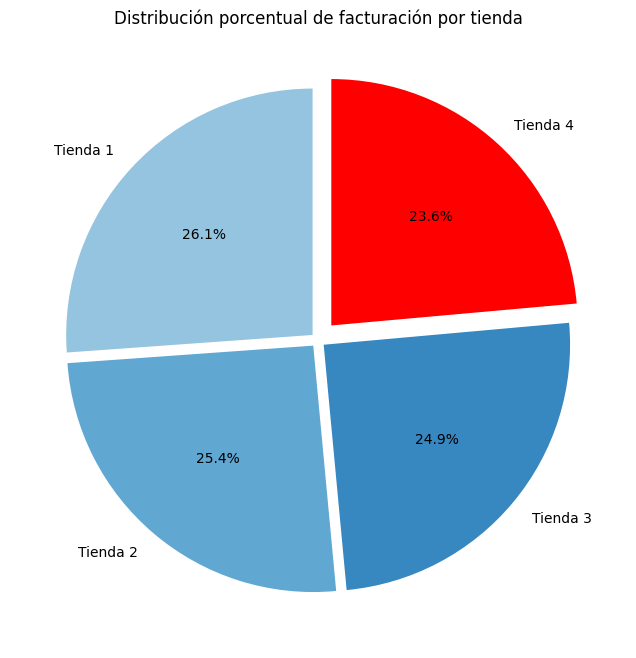

In [12]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"]
facturacion = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

# Encontrar la tienda con menor facturación
indice_min = np.argmin(facturacion)

# Crear colores degradados
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(tiendas)))

# Cambiar el menor valor a rojo
colors[indice_min] = [1, 0, 0, 1]

# Separación ligera
explode = [0.03]*4
explode[indice_min] = 0.08

plt.figure(figsize=(8,8))

plt.pie(
    facturacion,
    labels=tiendas,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode
)

plt.title("Distribución porcentual de facturación por tienda")

plt.show()

# 2. Ventas por categoría

In [8]:
categoria_tienda1 = tienda["Categoría del Producto"].value_counts()
categoria_tienda2 = tienda2["Categoría del Producto"].value_counts()
categoria_tienda3 = tienda3["Categoría del Producto"].value_counts()
categoria_tienda4 = tienda4["Categoría del Producto"].value_counts()

print("Ventas por categoría - Tienda 1")
print(categoria_tienda1)
print()

print("Ventas por categoría - Tienda 2")
print(categoria_tienda2)
print()

print("Ventas por categoría - Tienda 3")
print(categoria_tienda3)
print()

print("Ventas por categoría - Tienda 4")
print(categoria_tienda4)

Ventas por categoría - Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Ventas por categoría - Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Ventas por categoría - Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Ventas por

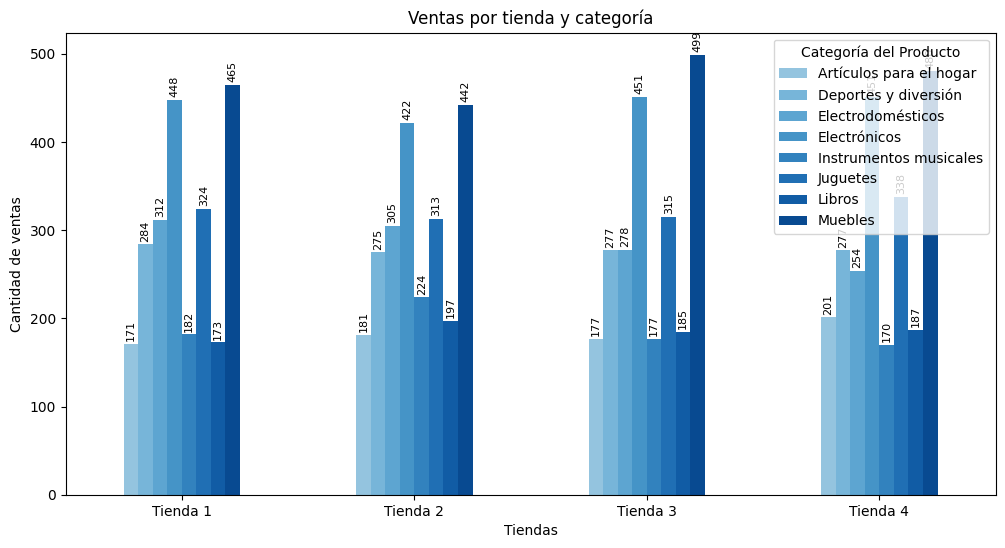

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_categorias = pd.DataFrame({
    "Tienda 1": categoria_tienda1,
    "Tienda 2": categoria_tienda2,
    "Tienda 3": categoria_tienda3,
    "Tienda 4": categoria_tienda4
}).fillna(0)

# Transponer el dataframe
df_categorias = df_categorias.T

# Colores degradados
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_categorias.columns)))

ax = df_categorias.plot(
    kind="bar",
    figsize=(12,6),
    color=colors
)

plt.title("Ventas por tienda y categoría")
plt.xlabel("Tiendas")
plt.ylabel("Cantidad de ventas")

plt.xticks(rotation=0)

# Mostrar valores
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=8,
        padding=2,
        rotation=90
    )

plt.show()

# 3. Calificación promedio de la tienda


In [18]:
calificacion_tienda1 = tienda["Calificación"].mean()
calificacion_tienda2 = tienda2["Calificación"].mean()
calificacion_tienda3 = tienda3["Calificación"].mean()
calificacion_tienda4 = tienda4["Calificación"].mean()

print("Calificación promedio Tienda 1:", calificacion_tienda1)
print("Calificación promedio Tienda 2:", calificacion_tienda2)
print("Calificación promedio Tienda 3:", calificacion_tienda3)
print("Calificación promedio Tienda 4:", calificacion_tienda4)

Calificación promedio Tienda 1: 3.976685036032217
Calificación promedio Tienda 2: 4.037303942348453
Calificación promedio Tienda 3: 4.048325561678677
Calificación promedio Tienda 4: 3.9957591178965224


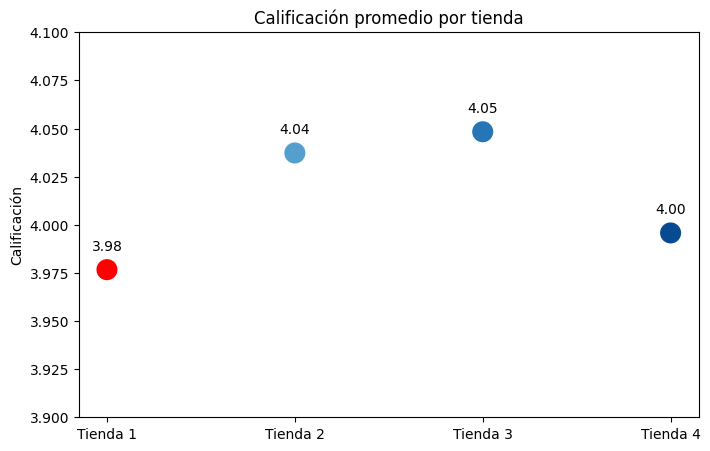

In [31]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

calificaciones = [
    calificacion_tienda1,
    calificacion_tienda2,
    calificacion_tienda3,
    calificacion_tienda4
]

indice_min = np.argmin(calificaciones)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(tiendas)))
colors[indice_min] = [1,0,0,1]

plt.figure(figsize=(8,5))

plt.scatter(tiendas, calificaciones, s=200, c=colors)

for i, val in enumerate(calificaciones):
    plt.text(i, val+0.01, f"{val:.2f}", ha="center")

plt.ylim(3.9,4.1)

plt.title("Calificación promedio por tienda")
plt.ylabel("Calificación")

plt.show()

# 4. Productos más y menos vendidos

In [23]:
print("Productos más vendidos")
print("-----------------------")
print("Tienda 1:", tienda["Producto"].value_counts().idxmax())
print("Tienda 2:", tienda2["Producto"].value_counts().idxmax())
print("Tienda 3:", tienda3["Producto"].value_counts().idxmax())
print("Tienda 4:", tienda4["Producto"].value_counts().idxmax())

print("\nProductos menos vendidos")
print("-----------------------")
print("Tienda 1:", tienda["Producto"].value_counts().idxmin())
print("Tienda 2:", tienda2["Producto"].value_counts().idxmin())
print("Tienda 3:", tienda3["Producto"].value_counts().idxmin())
print("Tienda 4:", tienda4["Producto"].value_counts().idxmin())

Productos más vendidos
-----------------------
Tienda 1: Microondas
Tienda 2: Iniciando en programación
Tienda 3: Kit de bancas
Tienda 4: Cama box

Productos menos vendidos
-----------------------
Tienda 1: Auriculares con micrófono
Tienda 2: Juego de mesa
Tienda 3: Bloques de construcción
Tienda 4: Guitarra eléctrica


# 5. Envío promedio por tienda

In [25]:
envio_tienda1 = tienda["Costo de envío"].mean()
envio_tienda2 = tienda2["Costo de envío"].mean()
envio_tienda3 = tienda3["Costo de envío"].mean()
envio_tienda4 = tienda4["Costo de envío"].mean()

print("Costo de envío promedio Tienda 1:", envio_tienda1)
print("Costo de envío promedio Tienda 2:", envio_tienda2)
print("Costo de envío promedio Tienda 3:", envio_tienda3)
print("Costo de envío promedio Tienda 4:", envio_tienda4)

Costo de envío promedio Tienda 1: 26018.60958033065
Costo de envío promedio Tienda 2: 25216.235693090293
Costo de envío promedio Tienda 3: 24805.680373039424
Costo de envío promedio Tienda 4: 23459.457167090754


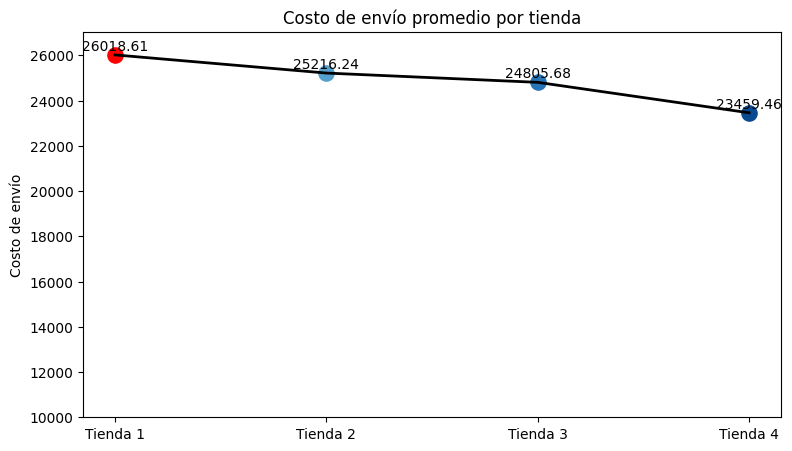

In [39]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"]

costos_envio = [
    envio_tienda1,
    envio_tienda2,
    envio_tienda3,
    envio_tienda4
]

indice_max = np.argmax(costos_envio)

colors = plt.cm.Blues(np.linspace(0.4,0.9,len(tiendas)))
colors[indice_max] = [1,0,0,1]

plt.figure(figsize=(9,5))

plt.plot(tiendas, costos_envio, color="black", linewidth=2)

for i in range(len(tiendas)):
    plt.scatter(tiendas[i], costos_envio[i], color=colors[i], s=120)

for i, valor in enumerate(costos_envio):
    plt.text(tiendas[i], valor+200, f"{valor:.2f}", ha="center")

plt.title("Costo de envío promedio por tienda")
plt.ylabel("Costo de envío")

# eje Y desde 10000
plt.ylim(10000, max(costos_envio) + 1000)

plt.show()

# Informe Final



## Introducción
El objetivo de este análisis fue evaluar el desempeño de las cuatro tiendas de la cadena Alura Store con el fin de recomendar cuál de ellas debería vender el Sr. Juan para iniciar un nuevo emprendimiento.

Tomando en cuenta cuál presenta el menor desempeño relativo dentro del conjunto analizado.

## Análisis de ingresos

Este análisis muestra diferencias claras en el desempeño económico de las tiendas. La Tienda 1 presenta los mayores ingresos, seguida por la Tienda 2 y la Tienda 3, que muestran resultados similares en términos de generación de ventas.

Por otro lado, la Tienda 4 registra el menor nivel de facturación entre las cuatro tiendas, lo que indica un menor volumen de ventas y un rendimiento inferior en comparación con las demás.

Este resultado sugiere que la Tienda 4 tiene una menor capacidad para generar ingresos dentro de la cadena.



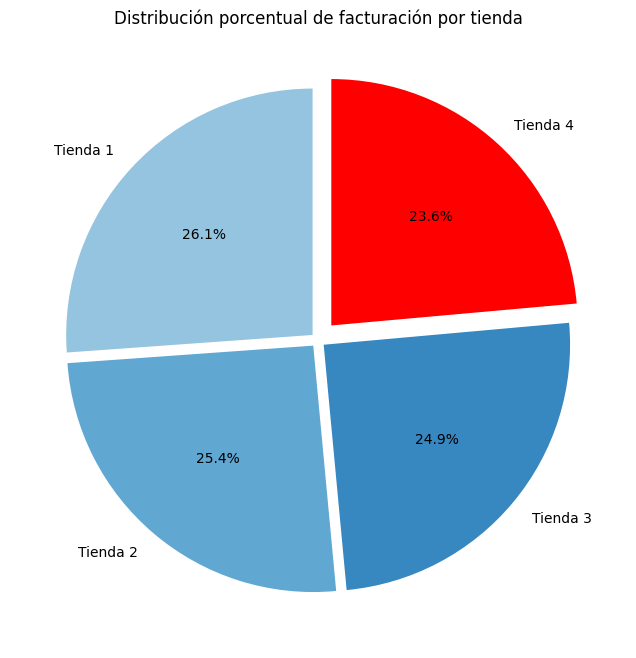

In [27]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"]
facturacion = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

# Encontrar la tienda con menor facturación
indice_min = np.argmin(facturacion)

# Crear colores degradados
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(tiendas)))

# Cambiar el menor valor a rojo
colors[indice_min] = [1, 0, 0, 1]

# Separación ligera
explode = [0.03]*4
explode[indice_min] = 0.08

plt.figure(figsize=(8,8))

plt.pie(
    facturacion,
    labels=tiendas,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode
)

plt.title("Distribución porcentual de facturación por tienda")

plt.show()

## Ventas por categoría
Se logro identificar que las categorías de Muebles y Electrónicos concentran la mayor cantidad de ventas dentro de las tiendas, siendo los principales impulsores del rendimiento comercial.

Otras categorías como Juguetes, Electrodomésticos y Deportes y diversión también presentan niveles relevantes de ventas, aunque con menor volumen en comparación con las principales.



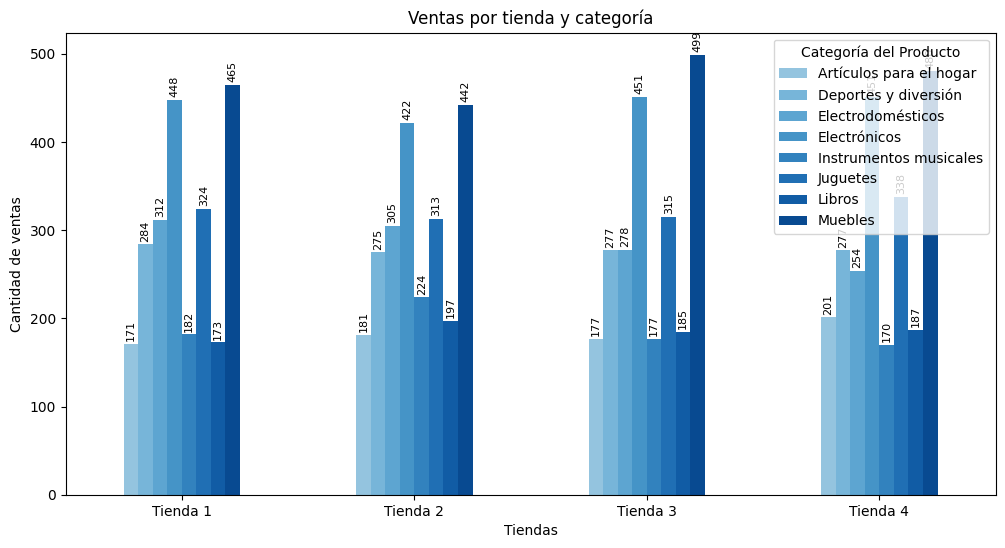

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_categorias = pd.DataFrame({
    "Tienda 1": categoria_tienda1,
    "Tienda 2": categoria_tienda2,
    "Tienda 3": categoria_tienda3,
    "Tienda 4": categoria_tienda4
}).fillna(0)

# Transponer el dataframe
df_categorias = df_categorias.T

# Colores degradados
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_categorias.columns)))

ax = df_categorias.plot(
    kind="bar",
    figsize=(12,6),
    color=colors
)

plt.title("Ventas por tienda y categoría")
plt.xlabel("Tiendas")
plt.ylabel("Cantidad de ventas")

plt.xticks(rotation=0)

# Mostrar valores
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=8,
        padding=2,
        rotation=90
    )

plt.show()

## Calificación promedio
Las calificaciones promedio de los clientes se mantienen relativamente similares entre las diferentes tiendas, lo que indica que en general la experiencia de compra es positiva.

Sin embargo, la tienda 3 presenta la mejor calificación promedio, lo que indica un mayor nivel de satisfacción de los clientes, mientras que la tienda 1 presenta la calificación más baja, aunque la variación es pequeña, esta puede reflejar diferencias en aspectos como la calidad del servicio, los tiempos de entrega o la satisfacción general con los productos adquiridos.


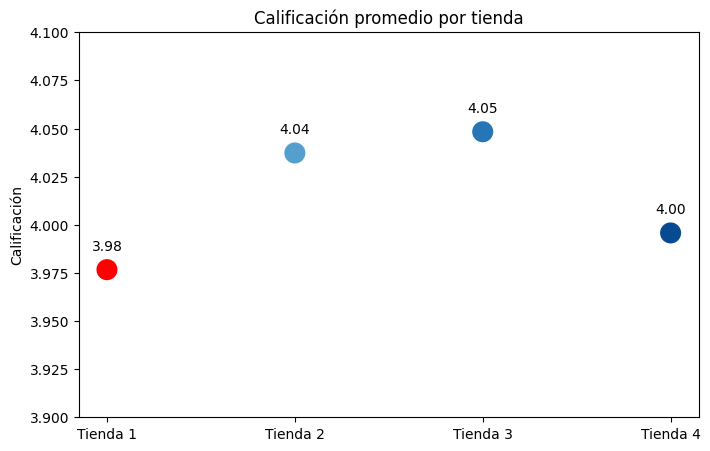

In [32]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

calificaciones = [
    calificacion_tienda1,
    calificacion_tienda2,
    calificacion_tienda3,
    calificacion_tienda4
]

indice_min = np.argmin(calificaciones)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(tiendas)))
colors[indice_min] = [1,0,0,1]

plt.figure(figsize=(8,5))

plt.scatter(tiendas, calificaciones, s=200, c=colors)

for i, val in enumerate(calificaciones):
    plt.text(i, val+0.01, f"{val:.2f}", ha="center")

plt.ylim(3.9,4.1)

plt.title("Calificación promedio por tienda")
plt.ylabel("Calificación")

plt.show()

## Productos más y menos vendidos

El análisis de los productos más y menos vendidos permitió identificar qué artículos presentan mayor rotación dentro de cada tienda.

**Productos más vendidos**

Tienda 1: Microondas

Tienda 2: Iniciando en programación

Tienda 3: Kit de bancas

Tienda 4: Cama box

**Productos menos vendidos**

Tienda 1: Auriculares con micrófono

Tienda 2: Juego de mesa

Tienda 3: Bloques de construcción

Tienda 4: Guitarra eléctrica


Los productos más vendidos reflejan las preferencias de los clientes y las categorías con mayor dinamismo comercial, mientras que los productos con menor número de ventas pueden representar oportunidades de mejora en la estrategia de inventario o comercialización.

Este análisis contribuye a comprender mejor la dinámica de ventas de cada tienda y el impacto de los diferentes productos en su rendimiento.


## Costo promedio de envío

El costo promedio de envío por tienda fue el siguiente:

Tienda 1: 26,018

Tienda 2: 25,216

Tienda 3: 24,856

Tienda 4: 23,459

En este caso se observa que la Tienda 1 tiene el costo de envío más alto, mientras que la Tienda 4 presenta el costo de envío más bajo y por lo tanto una logística relativamente más eficiente en términos de costos de envío.


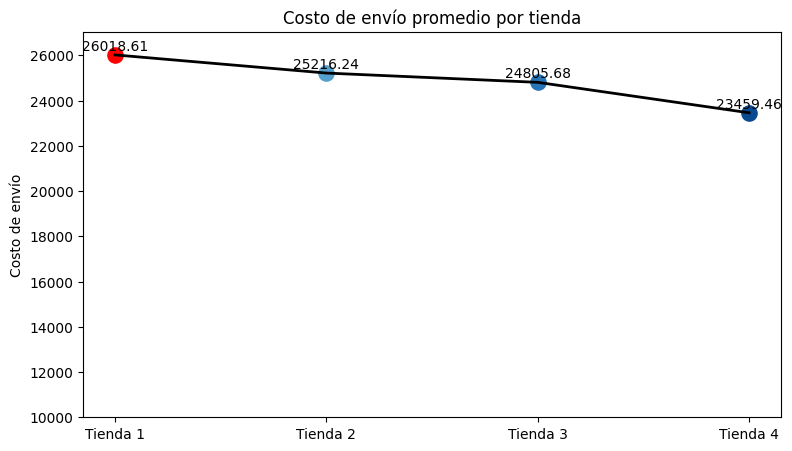

In [40]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"]

costos_envio = [
    envio_tienda1,
    envio_tienda2,
    envio_tienda3,
    envio_tienda4
]

indice_max = np.argmax(costos_envio)

colors = plt.cm.Blues(np.linspace(0.4,0.9,len(tiendas)))
colors[indice_max] = [1,0,0,1]

plt.figure(figsize=(9,5))

plt.plot(tiendas, costos_envio, color="black", linewidth=2)

for i in range(len(tiendas)):
    plt.scatter(tiendas[i], costos_envio[i], color=colors[i], s=120)

for i, valor in enumerate(costos_envio):
    plt.text(tiendas[i], valor+200, f"{valor:.2f}", ha="center")

plt.title("Costo de envío promedio por tienda")
plt.ylabel("Costo de envío")

# eje Y desde 10000
plt.ylim(10000, max(costos_envio) + 1000)

plt.show()

## Conclusión

Considerando todos los indicadores analizados, se observa que la Tienda 4 presenta el menor desempeño general en comparación con las demás tiendas.

Aunque la Tienda 4 cuenta con el menor costo de envío, también presenta la menor facturación total, lo que indica un menor volumen de ventas y un rendimiento comercial inferior.

Por otro lado, la Tienda 1 lidera en ingresos, mientras que la Tienda 3 presenta la mejor calificación de clientes, lo que refleja un buen equilibrio entre ventas y satisfacción del cliente.

En función de estos resultados, se recomienda que el Sr. Juan considere vender la Tienda 4, ya que su rendimiento general es el más bajo dentro del conjunto analizado.